In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [40]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:

folder = "/content/drive/MyDrive/YELP"
df = pd.read_csv(f"{folder}/merge_yelp_750k.csv")

print(df.shape)
df.head()

(750000, 22)


,review_id,user_id,business_id,stars_review,useful,funny,cool,text,date,year,...,text_cl,name,address,city,state,postal_code,categories,stars_business,review_count,is_open
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,2018,...,"if you decide to eat here, just be aware it is...",Turning Point of North Wales,1460 Bethlehem Pike,North Wales,PA,19454,"Restaurants, Breakfast & Brunch, Food, Juice B...",3.0,169,1
1,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,2014,...,family diner. had the buffet. eclectic assortm...,Kettle Restaurant,748 W Starr Pass Blvd,Tucson,AZ,85713,"Restaurants, Breakfast & Brunch",3.5,47,1
2,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,2015,...,"wow! yummy, different, delicious. our favorite...",Zaika,2481 Grant Ave,Philadelphia,PA,19114,"Halal, Pakistani, Restaurants, Indian",4.0,181,1
3,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,2017,...,cute interior and owner ? gave us tour of upco...,Melt,2549 Banks St,New Orleans,LA,70119,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",4.0,32,0
4,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31,2015,...,i am a long term frequent customer of this est...,Dmitri's,795 S 3rd St,Philadelphia,PA,19147,"Mediterranean, Restaurants, Seafood, Greek",4.0,273,0


In [42]:
df[['stars_review', 'stars_business', 'review_count']].describe()

,stars_review,stars_business,review_count
count,750000.000000,750000.000000,750000.000000
mean,3.800560,3.782142,444.460939
std,1.368162,0.612794,613.348691
min,1.000000,1.000000,5.000000
25%,3.000000,3.500000,94.000000
50%,4.000000,4.000000,227.000000
75%,5.000000,4.000000,528.000000
max,5.000000,5.000000,4554.000000


In [43]:
df.groupby("stars_review").size().sort_index()

,0
stars_review,
1,84833
2,64608
3,88833
4,188758
5,322968


In [44]:
df["business_id"].nunique()

10042

In [45]:
top_rest = df.groupby("name")["business_id"].count().sort_values(ascending=False).head(10)
top_rest

,business_id
name,
Luke,4661
Drago's Seafood Restaurant,2846
McDonald's,2797
Santa Barbara Shellfish Company,2444
Sabrina's Café,2279
Prep & Pastry,2230
Surrey's Café & Juice Bar,2120
Mr. B's Bistro,2116
District Donuts Sliders Brew,2110


In [46]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
monthly = df.dropna(subset=["date"]).set_index("date").resample("ME")["stars_review"].mean()
monthly.head()

,stars_review
date,
2005-03-31,3.600000
2005-04-30,4.000000
2005-05-31,3.375000
2005-06-30,4.333333
2005-07-31,3.500000


---
## Data Visualization

/tmp/ipython-input-181615338.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=star_count.index, y=star_count.values, palette="viridis")


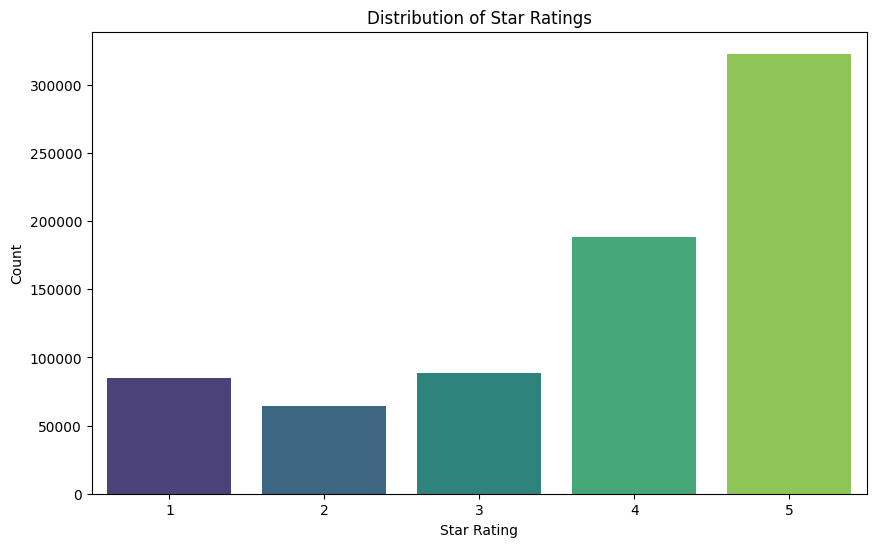

In [47]:
#star rating distribution
star_count = df['stars_review'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=star_count.index, y=star_count.values, palette="viridis")
plt.title('Distribution of Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.show()

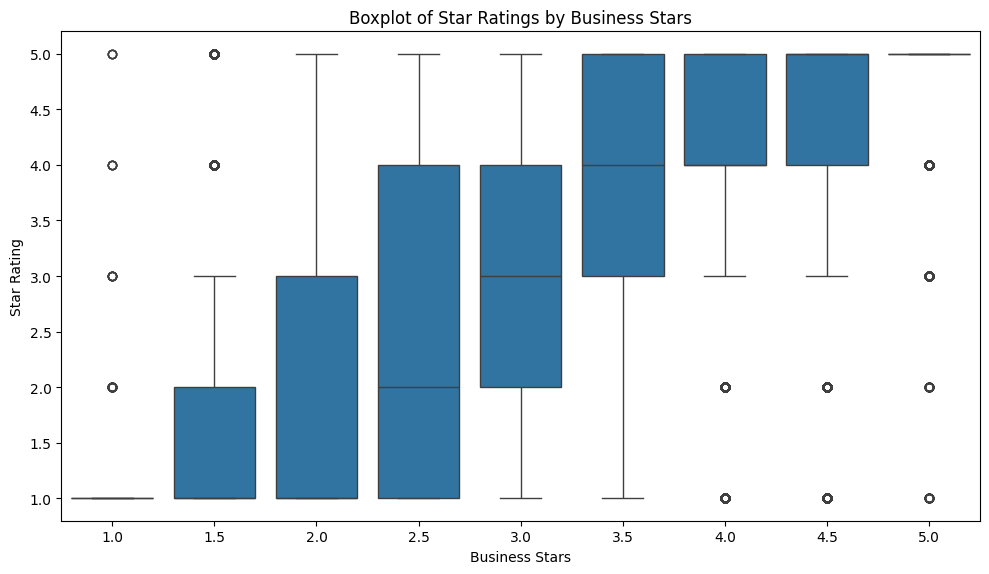

In [48]:
df_plot = df.copy()

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_plot,
    x="stars_business",
    y="stars_review",
    )
plt.title('Boxplot of Star Ratings by Business Stars')
plt.suptitle('')
plt.xlabel('Business Stars')
plt.ylabel('Star Rating')
plt.tight_layout()
plt.show()

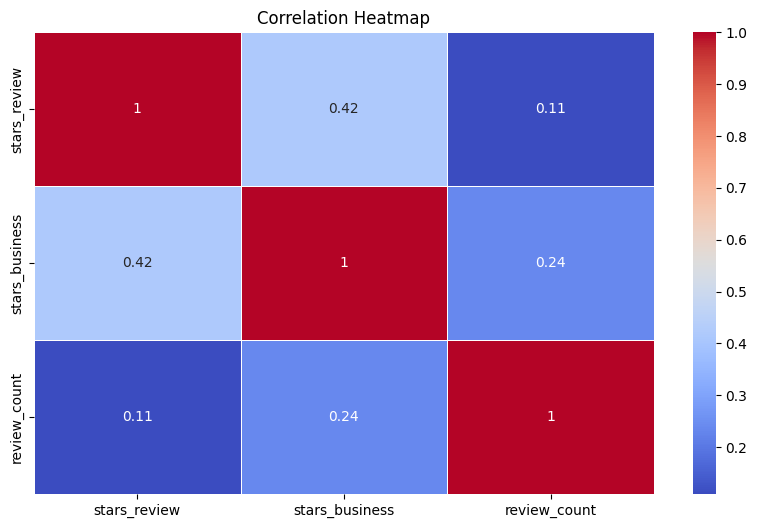

In [49]:
#heatmap

crr = df[["stars_review","stars_business","review_count"]].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(crr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

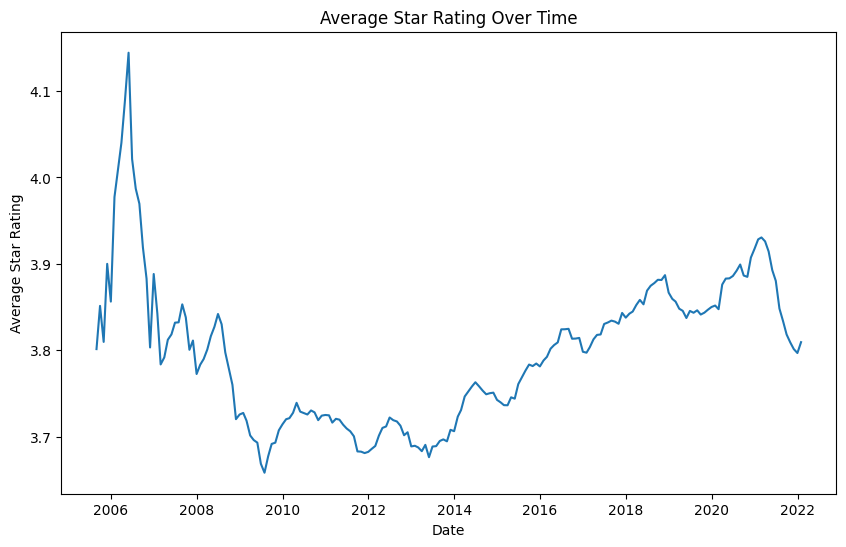

In [50]:
month_trend = df.set_index("date").resample("ME")["stars_review"].mean()


plt.figure(figsize=(10,6))
month_trend_rolling = month_trend.rolling(6).mean()

sns.lineplot(x=month_trend.index,
             y=month_trend_rolling,
             marker=None)
plt.title('Average Star Rating Over Time')
plt.xlabel('Date')
plt.ylabel('Average Star Rating')
plt.show()

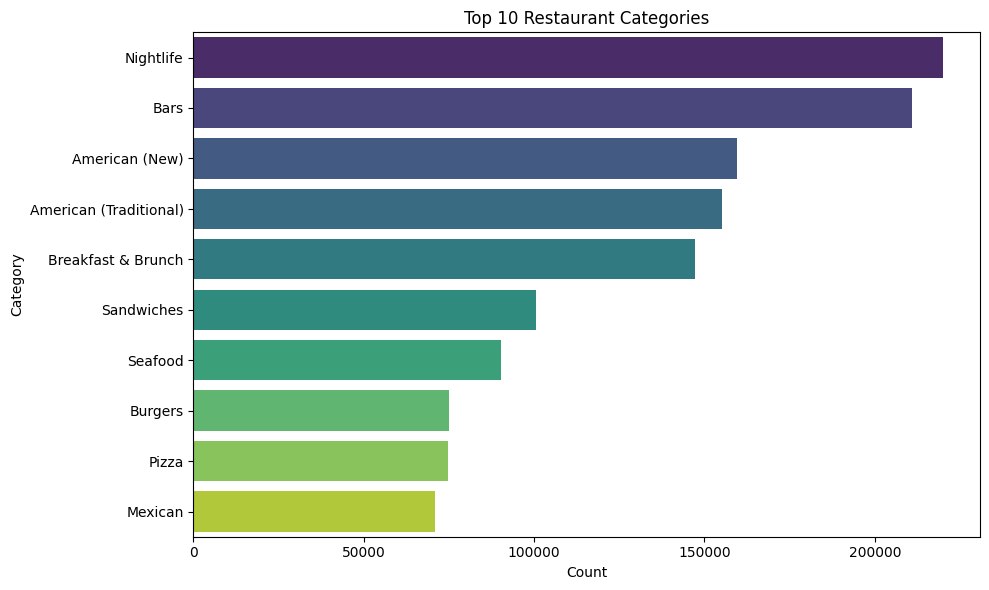

In [51]:
df_cat = df.copy()
df_cat["category_list"] = df_cat["categories"].str.split(", ")
df_cat = df_cat.explode("category_list")

rem = ["Restaurants", "Food"]
df_cat = df_cat[~df_cat["category_list"].isin(rem)]

#get top 10 now
top_cat = df_cat["category_list"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_cat.values,
    y=top_cat.index,
    hue=top_cat.index,
    palette="viridis",
    legend=False
)
plt.title("Top 10 Restaurant Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

---
##Feature Engineering

In [52]:
# converting star ratings into sentiment

df_model = df.copy()

In [53]:
df_model = df_model[df_model["stars_review"] != 3]
df_model["sentiment"] = df_model["stars_review"].apply(
    lambda x: 1 if x >= 4 else 0
)

print(df_model['sentiment'].value_counts())

sentiment
1    511726
0    149441
Name: count, dtype: int64


In [54]:
from sklearn.model_selection import train_test_split

X = df_model["text_cl"]
y = df_model["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 528933
Test size: 132234


In [55]:
# Fill NaN values with empty strings before vectorization
X_train_filled = X_train.fillna('')
X_test_filled = X_test.fillna('')

In [57]:
#convert text into numerical feature

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train_filled)
X_test_tfidf = tfidf.transform(X_test_filled)

print("tf-idf train shape: ", X_train_tfidf.shape)
print("tf-idf test shape: ", X_test_tfidf.shape)

tf-idf train shape:  (528933, 10000)
tf-idf test shape:  (132234, 10000)


In [59]:
#logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

LogisticRegression()

In [60]:
#evaluate model

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = lr.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9624831737677149

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.90      0.92     29888
           1       0.97      0.98      0.98    102346

    accuracy                           0.96    132234
   macro avg       0.95      0.94      0.95    132234
weighted avg       0.96      0.96      0.96    132234


Confusion Matrix:

[[ 26878   3010]
 [  1951 100395]]


---

In [21]:
#Linear Regression
df_lin = df.copy()

X = df_lin["text_cl"]
y = df_lin["stars_review"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42

)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 600000
Test size: 150000


In [23]:
X_train = X_train.fillna('')
X_test = X_test.fillna('')

In [24]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin = LinearRegression()
lin.fit(X_train_tfidf, y_train)

LinearRegression()

In [26]:
y_pred = lin.predict(X_test_tfidf)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("LINEAR Mean Squared Error:", mse)
print("LINEAR R-squared:", r2)
print("LINEAR Root Mean Squared Error:", rmse)

LINEAR Mean Squared Error: 0.5597759662943725
LINEAR R-squared: 0.7013963252116884
LINEAR Root Mean Squared Error: 0.7481817735646683


In [27]:
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_tfidf, y_train)

Ridge()

In [28]:
ridge_pred = ridge.predict(X_test_tfidf)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)

print("RIDGE Mean Squared Error:", ridge_mse)
print("RIDGE R-squared:", ridge_r2)
print("RIDGE Root Mean Squared Error:", ridge_rmse)

RIDGE Mean Squared Error: 0.5589801326804784
RIDGE R-squared: 0.701820850121541
RIDGE Root Mean Squared Error: 0.7476497393034244


In [29]:
#Lasso evaluation

lasso = Lasso(alpha=0.001, max_iter=5000)
lasso.fit(X_train_tfidf, y_train)

Lasso(alpha=0.001, max_iter=5000)

In [30]:
lasso_pred = lasso.predict(X_test_tfidf)

In [31]:
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("LASSO Mean Squared Error:", lasso_mse)
print("LASSO R-squared:", lasso_r2)
print("LASSO Root Mean Squared Error:", lasso_rmse)

LASSO Mean Squared Error: 0.9336759782129403
LASSO R-squared: 0.5019452514162746
LASSO Root Mean Squared Error: 0.9662691023793218


In [32]:
results = pd.DataFrame([
    {"Model":"Linear Regression", "MSE": mse, "RMSE": rmse, "R2": r2},
    {"Model":"Ridge (alpha=1.0)", "MSE": ridge_mse, "RMSE": ridge_rmse, "R2": ridge_r2},
    {"Model":"Lasso (alpha=0.0001)", "MSE": lasso_mse, "RMSE": lasso_rmse, "R2": lasso_r2},
])

results

,Model,MSE,RMSE,R2
0,Linear Regression,0.559776,0.748182,0.701396
1,Ridge (alpha=1.0),0.558980,0.747650,0.701821
2,Lasso (alpha=0.0001),0.933676,0.966269,0.501945


---
##Classification Models

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [34]:
dt = DecisionTreeClassifier(max_depth=15, random_state=42)
dt.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(max_depth=15, random_state=42)

In [35]:
dt_pred = dt.predict(X_test_tfidf)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.51422

Decision Tree Classification Report:

              precision    recall  f1-score   support

           1       0.64      0.43      0.51     17006
           2       0.31      0.07      0.12     12988
           3       0.32      0.14      0.20     17625
           4       0.39      0.33      0.35     37800
           5       0.56      0.84      0.67     64581

    accuracy                           0.51    150000
   macro avg       0.44      0.36      0.37    150000
weighted avg       0.48      0.51      0.47    150000



In [36]:
#Random Forrest

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(max_depth=15, random_state=42)

In [37]:
rf_pred = rf.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.46204

Random Forest Classification Report:

              precision    recall  f1-score   support

           1       0.72      0.24      0.36     17006
           2       0.59      0.00      0.00     12988
           3       0.42      0.00      0.00     17625
           4       0.32      0.02      0.04     37800
           5       0.45      1.00      0.62     64581

    accuracy                           0.46    150000
   macro avg       0.50      0.25      0.21    150000
weighted avg       0.46      0.46      0.32    150000



In [38]:
#Hyperperameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


In [40]:
grid.fit(X_train_tfidf, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'class_weight': [None, 'balanced']},
             scoring='accuracy', verbose=1)

In [41]:
print("Best Parameters: ", grid.best_params_)
print("Best Score: ", grid.best_score_)
best_log = grid.best_estimator_

Best Parameters:  {'C': 1, 'class_weight': None}
Best Score:  0.6564933333333334


In [42]:
best_log = grid.best_estimator_
y_pred_b = best_log.predict(X_test_tfidf)

print("Best Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_b))
print("\nBest Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_b))
print("\nBest Logistic Regression Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_b))

Best Logistic Regression Accuracy: 0.6598466666666667

Best Logistic Regression Classification Report:

              precision    recall  f1-score   support

           1       0.70      0.79      0.74     17006
           2       0.48      0.37      0.42     12988
           3       0.51      0.41      0.45     17625
           4       0.55      0.49      0.52     37800
           5       0.75      0.85      0.80     64581

    accuracy                           0.66    150000
   macro avg       0.60      0.58      0.59    150000
weighted avg       0.64      0.66      0.65    150000


Best Logistic Regression Confusion Matrix:

[[13438  2195   652   266   455]
 [ 3945  4783  3014   765   481]
 [ 1124  2396  7164  5353  1588]
 [  369   385  2816 18413 15817]
 [  294   119   499  8490 55179]]


In [43]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(best_log, "best_logistic_model.pkl")

['best_logistic_model.pkl']

---
##Deep Learning

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [16]:
df_dl = df.copy()

df_dl = df_dl[df_dl["stars_review"] != 3].copy()
df_dl["sentiment"] = (df_dl["stars_review"] >= 4).astype(int)

df_dl = df_dl.sample(n=50000, random_state=42)
df_dl["sentiment"].value_counts()


,count
sentiment,
1,38660
0,11340


In [18]:
from sklearn.model_selection import train_test_split

X = df_dl["text_cl"]
y = df_dl["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 40000
Test size: 10000


In [19]:
X_train = X_train.fillna('')
X_test = X_test.fillna('')

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("tf-idf train shape: ", X_train_tfidf.shape)
print("tf-idf test shape: ", X_test_tfidf.shape)

tf-idf train shape:  (40000, 5000)
tf-idf test shape:  (10000, 5000)


In [22]:
X_train_d = X_train_tfidf.toarray()
X_test_d = X_test_tfidf.toarray()

In [25]:
mdl = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_d.shape[1],)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

mdl.compile(
    loss='binary_crossentropy',
    optimizer="adam",
    metrics=['accuracy']
)

In [26]:
hist = mdl.fit(
    X_train_tfidf.toarray(),
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=512
)


Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.7629 - loss: 0.5146 - val_accuracy: 0.9356 - val_loss: 0.2014
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9525 - loss: 0.1465 - val_accuracy: 0.9476 - val_loss: 0.1367
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9734 - loss: 0.0778 - val_accuracy: 0.9474 - val_loss: 0.1477


In [27]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_prob = mdl.predict(X_test_d).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Test Accuracy: 0.949

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89      2268
           1       0.97      0.96      0.97      7732

    accuracy                           0.95     10000
   macro avg       0.92      0.93      0.93     10000
weighted avg       0.95      0.95      0.95     10000


Confusion Matrix:
 [[2048  220]
 [ 290 7442]]


In [28]:
#LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

m_words = 20000
m_len = 200

tok = Tokenizer(num_words=m_words, oov_token="<OOV>")
tok.fit_on_texts(X_train)


In [29]:
X_train_seq = tok.texts_to_sequences(X_train)
X_test_seq = tok.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=m_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=m_len, padding="post", truncating="post")

In [30]:
lstm = Sequential([
    Embedding(m_words, 128, input_length=m_len),
    LSTM(128),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

lstm.compile(
    loss='binary_crossentropy',
    optimizer="adam",
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
hist_l = lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=512
)

Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.7723 - loss: 0.5552 - val_accuracy: 0.7753 - val_loss: 0.5281
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.7709 - loss: 0.5320 - val_accuracy: 0.7753 - val_loss: 0.5255
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.7803 - loss: 0.5192 - val_accuracy: 0.8499 - val_loss: 0.5028


In [33]:
y_prod_l = lstm.predict(X_test_pad).ravel()
y_pred_l = (y_prod_l >= 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred_l))
print("\nClassification Report:\n", classification_report(y_test, y_pred_l))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_l))

313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step
Test Accuracy: 0.8472

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.64      0.65      2268
           1       0.90      0.91      0.90      7732

    accuracy                           0.85     10000
   macro avg       0.78      0.77      0.78     10000
weighted avg       0.84      0.85      0.85     10000


Confusion Matrix:
 [[1447  821]
 [ 707 7025]]


In [36]:
!pip -q install transformers

In [37]:
from transformers import pipeline

bert = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

bert(X_test.iloc[0])

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998455047607422}]

In [42]:
sample_per_class = 150
df_eval = pd.DataFrame({"test": X_test, "actual": y_test})
df_eval = df_eval.groupby("actual", group_keys=False).apply(
    lambda x: x.sample(min(sample_per_class, len(x)), random_state=42)
    )

/tmp/ipython-input-1567217481.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_eval = df_eval.groupby("actual", group_keys=False).apply(


In [43]:
x_eval = df_eval["test"].tolist()
y_eval = df_eval["actual"].tolist()

In [45]:
preds = bert(x_eval, batch_size=32, truncation=True)
y_hat = np.array([1 if pred["label"] == "POSITIVE" else 0 for pred in preds])

In [46]:
print("Transformer Accuracy:", accuracy_score(y_eval, y_hat))
print("\nClassification Report:\n", classification_report(y_eval, y_hat))
print("\nConfusion Matrix:\n", confusion_matrix(y_eval, y_hat))

Transformer Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       150
           1       0.97      0.96      0.97       150

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300


Confusion Matrix:
 [[146   4]
 [  6 144]]


---
##LLM

In [16]:
!pip -q install openai

In [76]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("openai")

In [77]:
from openai import OpenAI
client = OpenAI()

In [78]:
def summarize_restaurant(reviews):
  prompt = f"""

 You are a restaurant review analyst.

Based on the following customer reviews, write a concise summary in 4–6 natural sentences.

Write in paragraph form (NOT bullet points, NOT numbered lists).

Include:
- Overall sentiment
- Key strengths
- Main complaints (if any)


  Reviews:
  {reviews}
  """
  response = client.chat.completions.create(
      model="gpt-4o-mini",
      messages=[
          {"role": "system", "content": "You analyze restaurant reviews."},
          {"role": "user", "content": prompt}
      ],
      temperature=0.3,
      max_tokens=180
  )

  return response.choices[0].message.content

In [79]:
#testing

rest_name = "Luke"

subset = df[df["name"] == rest_name]
top_rev = subset["text_cl"].head(20)

combined_text = " ".join(top_rev.tolist())

summary = summarize_restaurant(combined_text)

print(summary)

Overall, the sentiment towards Luke's restaurant is mixed, with many patrons praising the food and service, while others express disappointment in specific experiences. Key strengths highlighted include the quality of the seafood, particularly the oysters and shrimp and grits, as well as the attentive and friendly service from the staff, even during busy times. Diners also appreciate the vibrant atmosphere and the delicious bread pudding. However, complaints arise regarding slow service during peak hours, issues with bill splitting for large parties, and some dissatisfaction with certain dishes, such as the overcooked swordfish and salty squash. Additionally, a few customers noted that the pricing for drinks and substitutions felt excessive. Despite these drawbacks, many guests recommend the restaurant for its standout dishes and overall enjoyable dining experience.


---
##Gradio Interface for user access

In [80]:
!pip -q install gradio joblib

In [81]:
import gradio as gr
import joblib

In [110]:
df = pd.read_csv("APP_DATA.csv")

In [111]:
model = joblib.load("best_logistic_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")


In [112]:
rest_names = sorted(df["name"].dropna().unique().tolist())

In [113]:
def get_restaurant(name: str, nrev: int):
  sub = df[df["name"] == name].copy()
  if len(sub) == 0:
    return None

  sub = sub.head(int(nrev))

  cats = sub["categories"].iloc[0] if "categories" in sub.columns else None


  stars_bus = sub["stars_business"].mean()
  stars_rev = sub["stars_review"].mean()

  if "text_cl" not in sub.columns:
    combined_reviews = ""
  else:
    combined_reviews = " ".join(sub["text_cl"].astype(str).tolist())

  return sub, cats, stars_bus, stars_rev, combined_reviews





In [129]:
def pred_sentiment(text: str):
  x = tfidf.transform([text])
  pred = model.predict(x)[0]

  #Confidence Interval
  conf_txt = "Probability Not Available."
  if hasattr(model, "predict_proba"):
    probs = model.predict_proba(x)[0]
    conf_val = float(probs.max())
    bar = "█" * int(conf_val * 10) + "░" * (10 - int(conf_val * 10))
    conf_txt = f"{bar} {conf_val:.2f}"

  return pred, conf_txt


In [130]:
def summarize_restaurant(reviews: str):
    # If no key, don’t crash
    if not os.environ.get("OPENAI_API_KEY"):
        return "OPENAI_API_KEY not set (summary disabled)."

    prompt = f"""
Summarize these restaurant reviews in 4-6 sentences.
Include overall sentiment, key strengths, and key complaints.

Reviews:
{reviews}
""".strip()

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You analyze restaurant reviews."},
            {"role": "user", "content": prompt},
        ],
        temperature=0.3,
    )

    return response.choices[0].message.content

In [131]:
def visual(avg):
    if avg is None or pd.isna(avg):
        return "N/A"
    return f"{avg:.2f} " + ("⭐" * int(round(avg)))

In [132]:
def restaurant_sum(name: str, nrev: int):
  pack = get_restaurant(name, nrev)
  if pack is None:
    return "Restaurant not found."

  sub, cats, stars_bus, stars_rev, combined_reviews = pack

  if not combined_reviews.strip():
    return "No reviews available."

  pred, conf = pred_sentiment(combined_reviews)
  labels = {
      1: "Very Negative",
      2: "Negative",
      3: "Neutral",
      4: "Positive",
      5: "Very Positive"
  }

  pred_label = labels.get(int(pred), str(pred))

  summary = summarize_restaurant(combined_reviews)

  dashboard = f"""
Restaurant: {name}
Reviews used: {len(sub)}
Business Stars (Yelp overall): {visual(stars_bus)}
Avg Review Stars: {visual(stars_rev)}
Categories: {cats}
""".strip()

  return dashboard, pred_label, conf, summary

In [136]:
with gr.Blocks(
    theme=gr.themes.Soft(),
    title="Yelp Restaurant Review Analyzer",

    ) as demo:
    gr.Markdown("Yelp Restaurant Review Analyzer")
    gr.Markdown("TF-IDF + Logistic Regression + LLM Summary")
    with gr.Row():
      restaurant = gr.Dropdown(
          choices=rest_names,
          label="Select Restaurant Name",
          value=rest_names[0] if len(rest_names) else None
          )
      nrev = gr.Slider(
          minimum=5,
          maximum=50,
          value=20,
          step=5,
          label="Number of reviews to use"
          )

    run_btm = gr.Button("Run Analysis", variant="primary")

    dashboard = gr.Textbox(label="Restaurant Dashboard", lines=6)
    sentiment = gr.Textbox(label="Model Sentiment Prediction")
    confidence = gr.Textbox(label="Model Confidence")
    summary = gr.Textbox(label="AI Summary Of Reviews", lines=7)

    run_btm.click(
        restaurant_sum,
        inputs=[restaurant, nrev],
        outputs=[dashboard, sentiment, confidence, summary]
    )

demo.launch(share=True)

/tmp/ipython-input-2282947223.py:1: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipython-input-2282947223.py:1: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://454d70993bd8f382c1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
